<a href="https://colab.research.google.com/github/Optimus0205/Data_Science_Project/blob/main/EDA_(univariate).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('/content/gurgaon_properties_cleaned_v2.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,...,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,...,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,...,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,...,1134.0,NaN,NaN,1,0,0,0,0,0,110


In [4]:
df.shape

(3472, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3472 non-null   object 
 1   society              3472 non-null   object 
 2   sector               3472 non-null   object 
 3   price                3454 non-null   float64
 4   price_per_sqft       3454 non-null   float64
 5   area                 3454 non-null   float64
 6   areaWithType         3472 non-null   object 
 7   bedRoom              3472 non-null   int64  
 8   bathroom             3472 non-null   int64  
 9   balcony              3472 non-null   object 
 10  floorNum             3454 non-null   float64
 11  facing               2571 non-null   object 
 12  agePossession        3472 non-null   object 
 13  super_built_up_area  1758 non-null   float64
 14  built_up_area        1641 non-null   float64
 15  carpet_area          1778 non-null   f

In [6]:
df.duplicated().sum()

np.int64(83)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.shape

(3389, 23)

Now starting analysis column wise

### 1. property_type

<Axes: xlabel='property_type'>

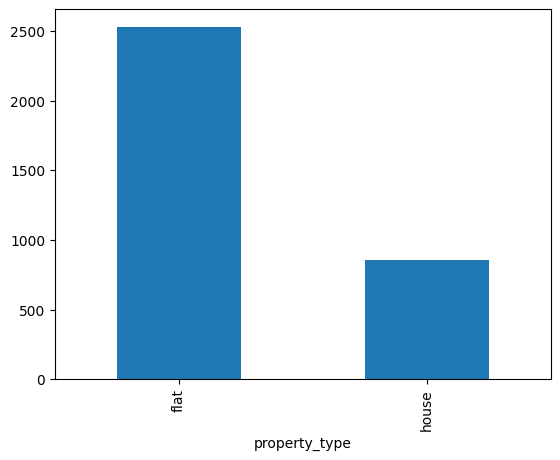

In [9]:
df['property_type'].value_counts().plot(kind='bar')

Observations :

*   Flats are in majority(75 percent) and there are less number of houses(~25 percent)
*   No missing value




### 2. society

In [10]:
df['society'].value_counts().shape

(629,)

In [11]:
df['society'].value_counts()

,count
society,
independent,486
tulip violet,75
ss the leaf,72
dlf new town heights,42
shapoorji pallonji joyville gurugram,41
...,...
dlf the crest,1
bhim nagar society,1
naman residency,1


In [12]:
df[df['society'] != 'independent']['society'].value_counts(normalize=True).cumsum().head(69)

,proportion
society,
tulip violet,0.025835
ss the leaf,0.050637
dlf new town heights,0.065105
shapoorji pallonji joyville gurugram,0.079228
shree vardhman victoria,0.090596
...,...
umang winter hills,0.484671
godrej oasis,0.488805
central park flower valley,0.492938


In [13]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(84),
 'Low (2-9)': np.int64(259),
 'Very Low (1)': np.int64(283)}

<Axes: xlabel='society'>

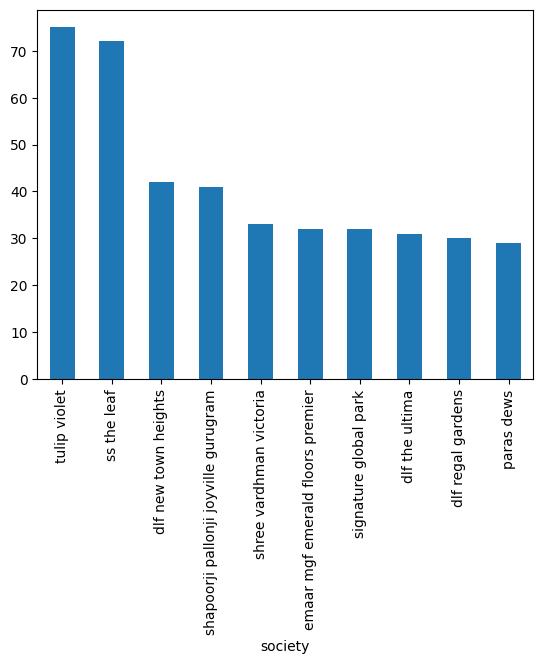

In [14]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [15]:
df['society'].isnull().sum()

np.int64(0)

Observations


*   Around 14% properties comes under independent tag.
*   There are 629 societies.
*   The top 69 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 560 societies->

    ->Very High (>100): Only 1 society has more than 100 listings.

    ->High (50-100): 2 societies have between 50 to 100 listings.

    ->Average (10-49): 84 societies fall in this range with 10 to 49 listings each.

    ->Low (2-9): 259 societies have between 2 to 9 listings.

    ->Very Low (1): A significant number, 283 societies, have only 1 listing.
    
*   1 missing value

### 3. sector

In [16]:
# unique sectors
df['sector'].value_counts().shape

(113,)

<Axes: xlabel='sector'>

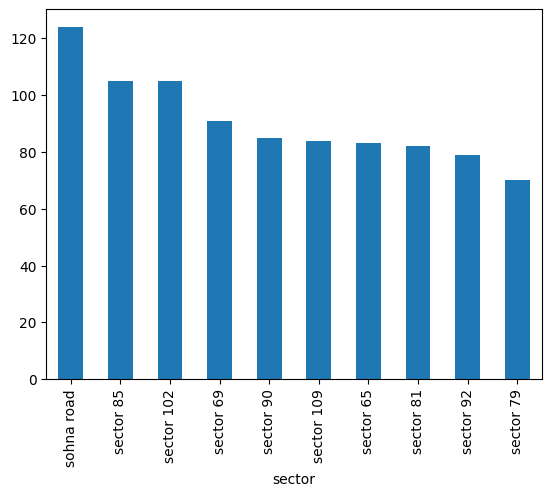

In [17]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [18]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(22),
 'Average (10-49)': np.int64(63),
 'Low (2-9)': np.int64(24),
 'Very Low (1)': np.int64(1)}

Observations



*   There are a total of 104 unique sectors in the dataset.
*   Frequency distribution of sectors:

    -Very High (>100): 3 sectors have more than 100 listings.

    -High (50-100): 22 sectors have between 50 to 100 listings.

    -Average (10-49): A majority, 63 sectors, fall in this range with 10 to 49 listings each.

    -Low (2-9): 24 sectors have between 2 to 9 listings.

    -Very Low (1): Interestingly, there is only 1 sector with only 1 listing.

### 4. price

In [19]:
df['price'].isnull().sum()

np.int64(17)

In [20]:
df['price'].describe()

,price
count,3372.000000
mean,2.646990
std,3.058565
min,0.070000
25%,0.990000
50%,1.600000
75%,2.912500
max,31.500000


<Axes: xlabel='price', ylabel='Count'>

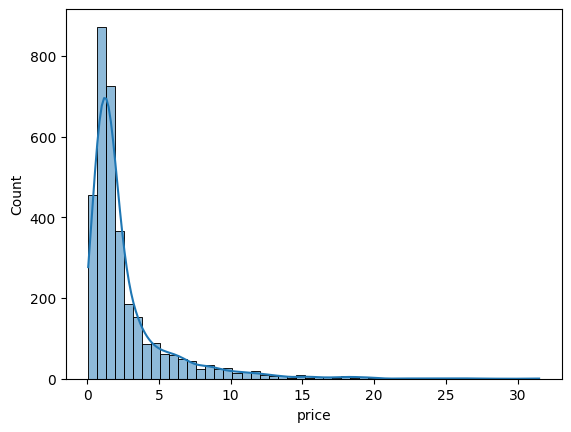

In [21]:
sns.histplot(df['price'],kde=True,bins=50)


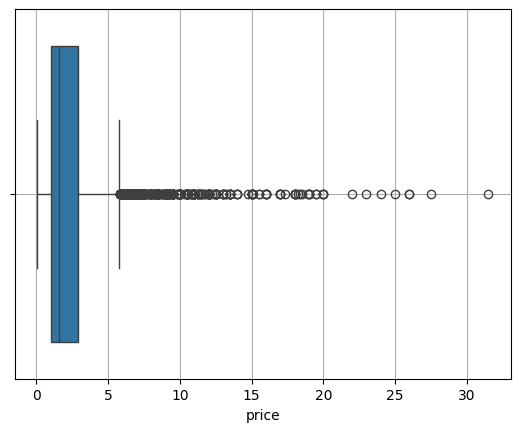

In [24]:
sns.boxplot(x=df['price'])
plt.grid()

*   Descriptive Statistics:

    -Count: There are 3,372 non-missing price entries.

    -Mean Price: The average price is approximately 2.64 crores.

    -Median Price: The median (or 50th percentile) price is 1.60 crores.

    -Standard Deviation: The prices have a standard deviation of 3.06, indicating variability in the prices.

    -Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.

    -IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.99 crores to 2.91 crores.

*   Visualizations:

    -Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.

    -Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

*   Missing Values: There are 17 missing values in the price column.

In [27]:
skewness=df['price'].skew()
kurtosis=df['price'].kurtosis()
print(skewness,kurtosis)

3.1852241754057937 14.040730931431264


**Skewness**: The price distribution has a skewness of approximately 3.18, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 14.04. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [28]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

,price
0.01,0.2571
0.05,0.4000
0.95,8.7725
0.99,16.0000


**Quantile Analysis**:

*   1% Quantile: Only 1% of properties are priced below 0.25 crores.
*   5% Quantile: 5% of properties are priced below 0.40 crores.
*   95% Quantile: 95% of properties are priced below 8.7 crores.
*   99% Quantile: 99% of properties are priced below 16 crores, indicating that very few properties are priced above this value.

In [29]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.9225)

In [30]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.89375 5.796250000000001


In [31]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(374, 23)

In [32]:
outliers['price'].describe()

,price
count,374.000000
mean,9.700481
std,4.106568
min,5.800000
25%,6.750000
50%,8.490000
75%,11.000000
max,31.500000


**Outliers Analysis** (using IQR method):

*   Based on the IQR method, there are 374 properties considered as outliers.
*   These outliers have an average price of approximately 9.7 crores.
*   The range for these outliers is from 5.8 crores to 31.5 crores.

<Axes: xlabel='price'>

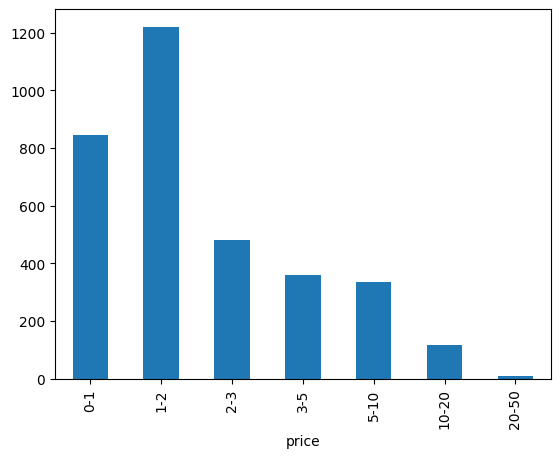

In [33]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

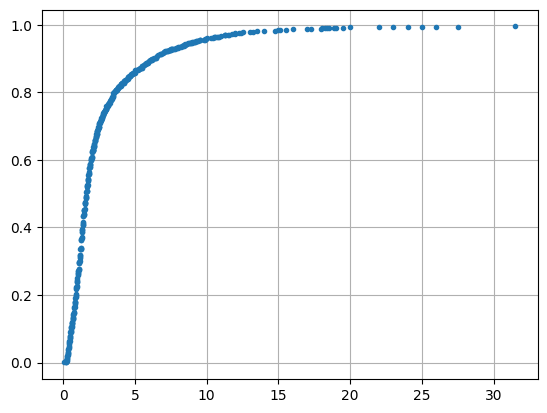

In [34]:
# ecdf plot -> cummulative sum plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

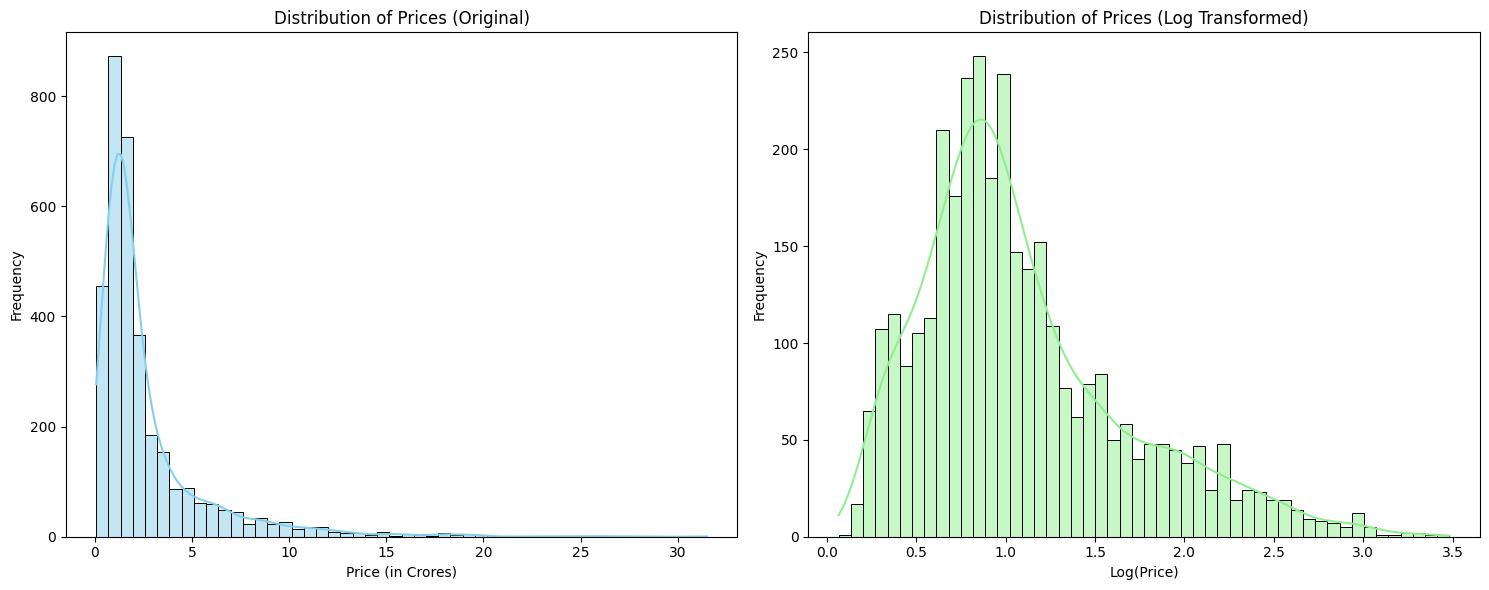

In [35]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**np.log1p**(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [36]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0355820202537842 0.8402241524114302


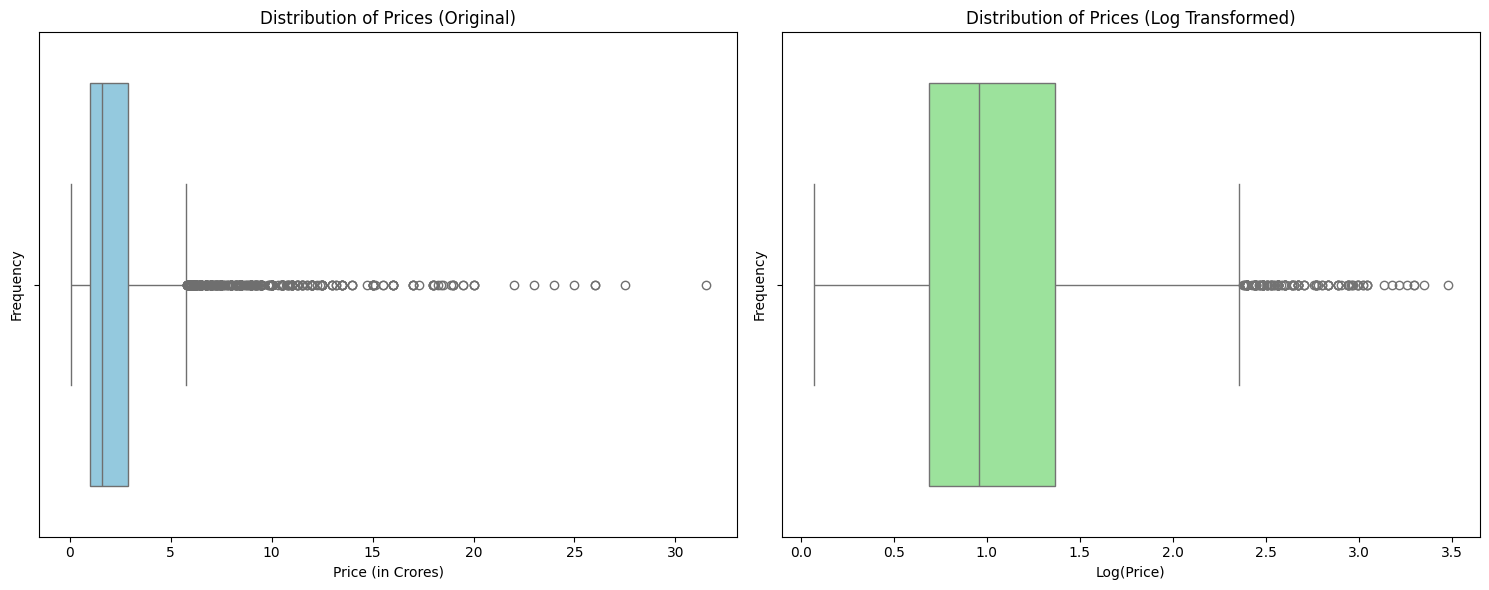

In [38]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(x=df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(x=np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### 5. price_per_aqft

In [39]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [40]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3372.000000
mean,14376.860024
std,24062.992038
min,4.000000
25%,7058.000000
50%,9253.500000
75%,14166.250000
max,600000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

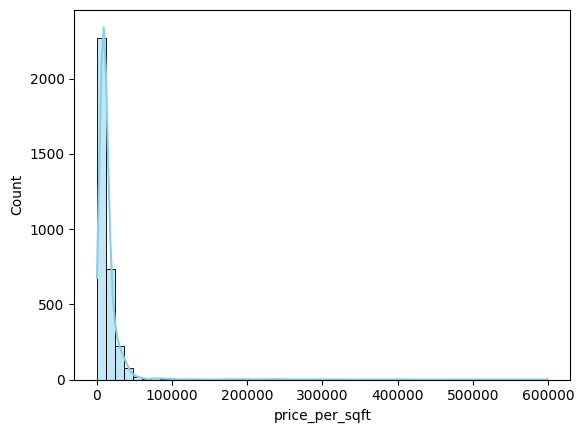

In [41]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: xlabel='price_per_sqft'>

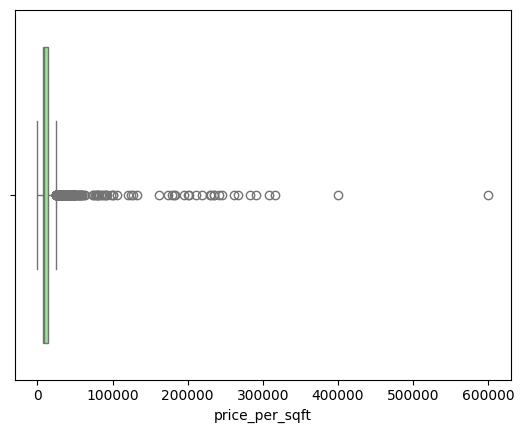

In [43]:
sns.boxplot(x=df['price_per_sqft'], color='lightgreen')

The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

**Observations**

*   Potential Outliers
*   Right Skewed
*   17 missing values

### 6. bedRoom

We have left area and areaWithType

In [44]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

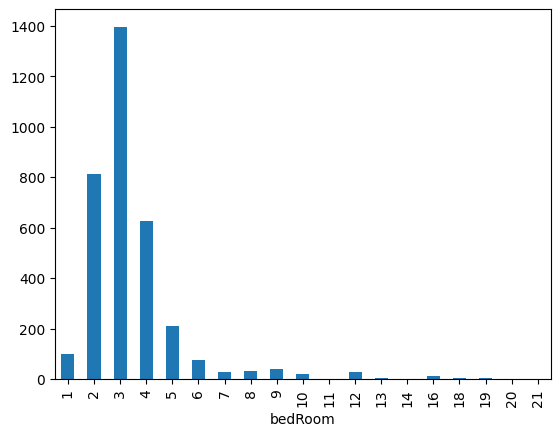

In [45]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

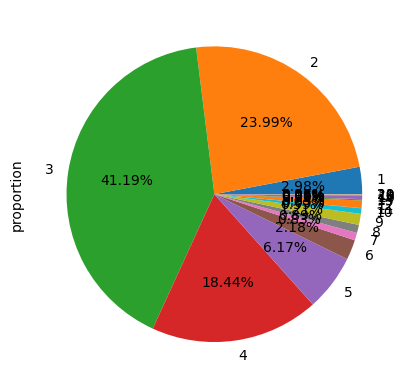

In [49]:
df['bedRoom'].value_counts(normalize=True).sort_index().plot(kind='pie',autopct='%0.2f%%')

<Axes: ylabel='proportion'>

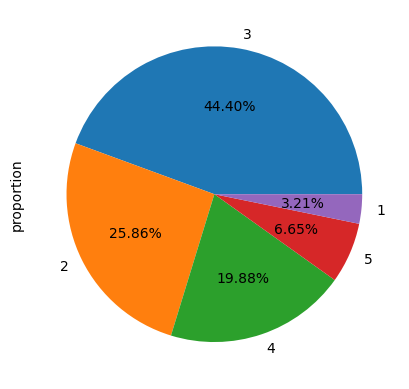

In [51]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

<Axes: ylabel='proportion'>

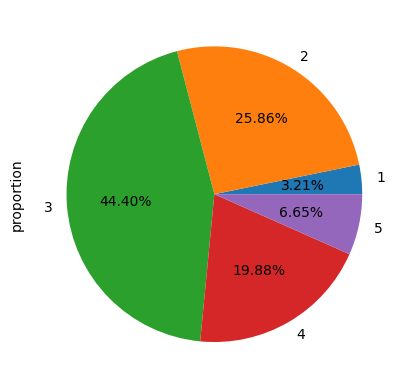

In [50]:
df['bedRoom'].value_counts(normalize=True).head().sort_index().plot(kind='pie',autopct='%0.2f%%')

### 7. bathroom

In [52]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

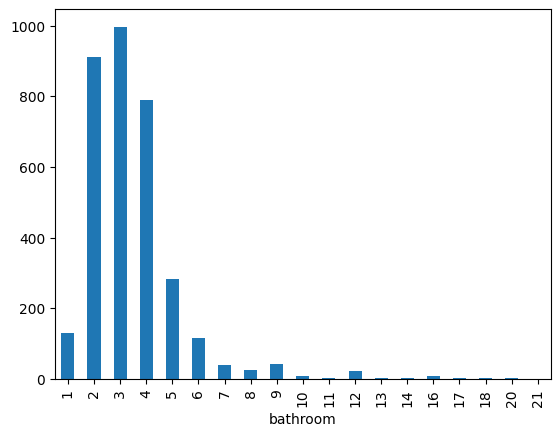

In [53]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

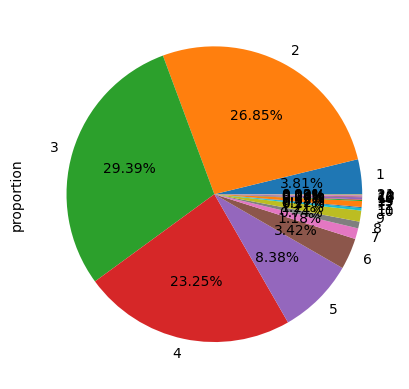

In [54]:
df['bathroom'].value_counts(normalize=True).sort_index().plot(kind='pie',autopct='%0.2f%%')

In [55]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,...,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,...,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,...,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,...,1134.0,NaN,NaN,1,0,0,0,0,0,110


In [56]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,...,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,...,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,...,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,...,1134.0,NaN,NaN,1,0,0,0,0,0,110


### 8. balcony

In [57]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

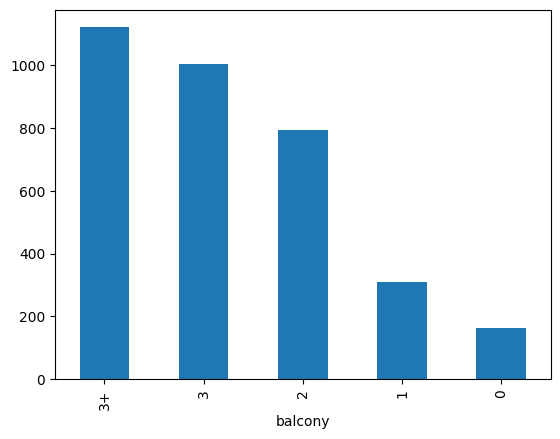

In [58]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

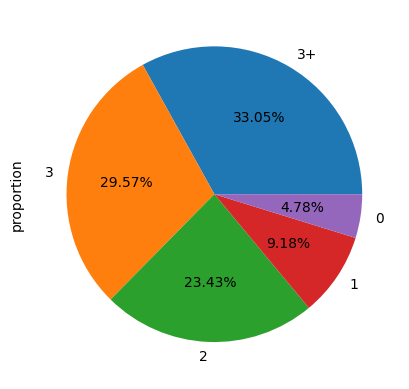

In [59]:
df['balcony'].value_counts(normalize=True).plot(kind='pie',autopct='%0.2f%%')

In [60]:
df.iloc[:,10:].head()df.iloc[:,10:].head()df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,10.0,NaN,Relatively New,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,0.0,South-East,Relatively New,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,10.0,NaN,Moderately Old,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,6.0,East,Relatively New,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,2.0,East,Relatively New,1134.0,NaN,NaN,1,0,0,0,0,0,110


### 9. floorNum

In [62]:
df['floorNum'].isnull().sum()

np.int64(18)

In [63]:
df['floorNum'].describe()

,floorNum
count,3371.000000
mean,6.774251
std,6.037892
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


<Axes: xlabel='floorNum'>

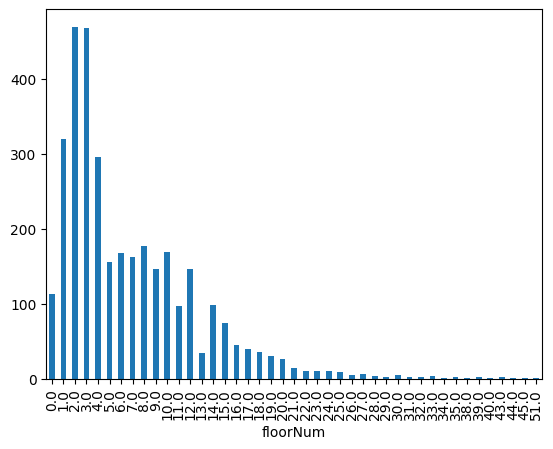

In [64]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

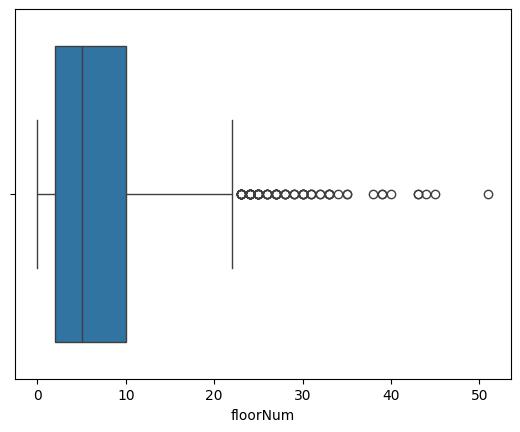

In [65]:
sns.boxplot(x=df['floorNum'])

*   The majority of the properties lie between the ground floor (0) and the 25th floor.
*   Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
*   There are a few properties located at higher floors, but their frequency is much lower.
*   The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
*   Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

### 10. facing

In [66]:
df['facing'].isnull().sum()

np.int64(864)

In [67]:
df['facing'].fillna('NA',inplace=True)

/tmp/ipykernel_3702/3692945726.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [68]:
df['facing'].value_counts()

,count
facing,
NA,864
North-East,598
East,578
North,366
West,243
South,228
North-West,191
South-East,169
South-West,151


### 11. agePossession

In [69]:
df['agePossession'].isnull().sum()

np.int64(0)

In [70]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1578
Moderately Old,535
New Property,511
Undefined,399
Old Property,284
Under Construction,82


### 12. areas

1.   super_built_up_area
2.   built_up_area
3.   carpet_area




In [71]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1656)

In [72]:
df['super_built_up_area'].describe()

,super_built_up_area
count,1733.000000
mean,1961.408598
std,760.030660
min,89.000000
25%,1530.000000
50%,1860.000000
75%,2262.000000
max,10000.000000


<Axes: xlabel='super_built_up_area', ylabel='Count'>

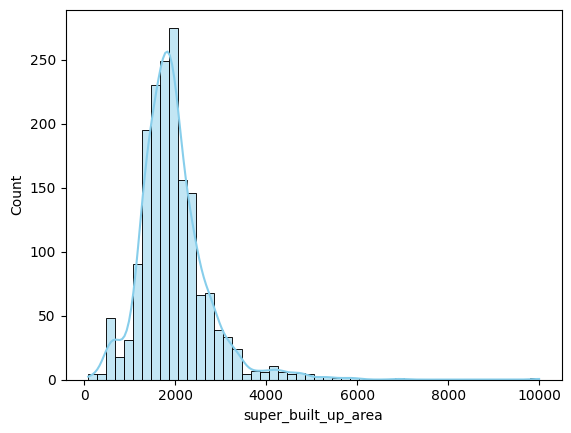

In [73]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: xlabel='super_built_up_area'>

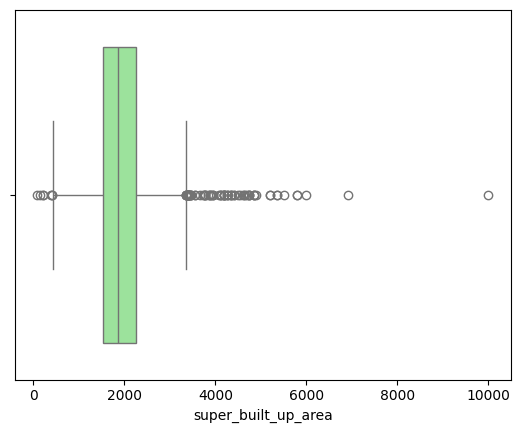

In [74]:
sns.boxplot(x=df['super_built_up_area'].dropna(), color='lightgreen')

*   Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
*   There are a few properties with a significantly larger area, leading to a right-skewed distribution.
*   The interquartile range (IQR) lies between roughly 1,530 sq.ft and 2,262 sq.ft, indicating that the middle 50% of the properties fall within this range.
*   There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [75]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1774)

In [79]:
df['built_up_area'].describe()

,built_up_area
count,1615.000000
mean,2423.797925
std,18353.279416
min,2.000000
25%,1103.000000
50%,1665.000000
75%,2430.000000
max,737147.000000


<Axes: xlabel='built_up_area', ylabel='Count'>

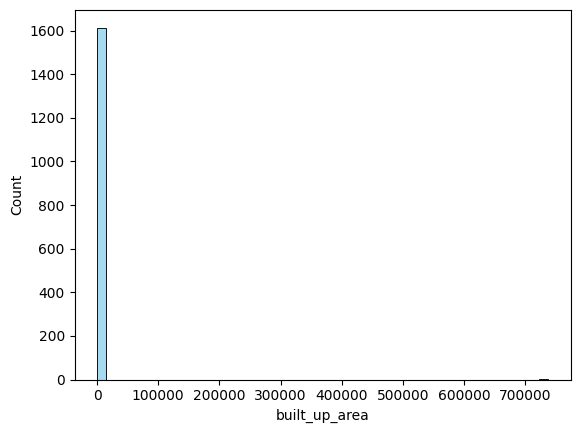

In [76]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='built_up_area'>

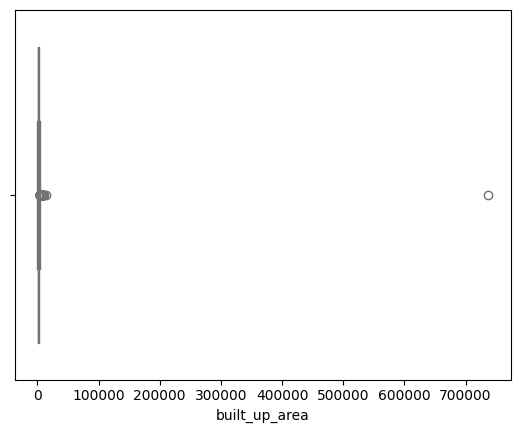

In [78]:
sns.boxplot(x=df['built_up_area'].dropna(), color='lightgreen')

*   Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
*   There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
*   The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.

The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.


In [80]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1664)

In [81]:
df['carpet_area'].describe()

,carpet_area
count,1725.000000
mean,2653.525333
std,23747.183364
min,15.000000
25%,867.240000
50%,1310.000000
75%,1800.000000
max,607936.000000


<Axes: xlabel='carpet_area', ylabel='Count'>

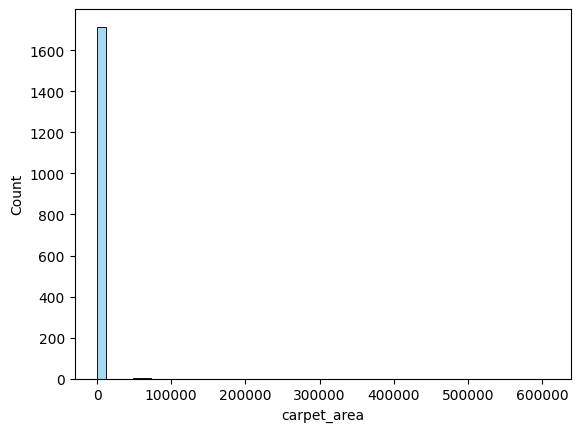

In [82]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='carpet_area'>

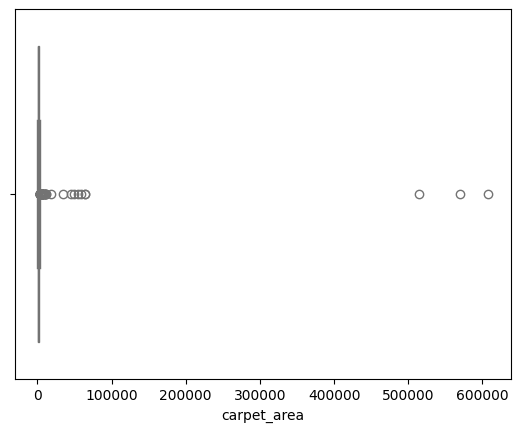

In [83]:
sns.boxplot(x=df['carpet_area'].dropna(), color='lightgreen')

In [84]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,1,0,0,0,0,0,72
1,0,0,0,0,0,0,157
2,0,1,0,0,0,1,120
3,0,1,0,0,0,1,174
4,1,0,0,0,0,0,110
...,...,...,...,...,...,...,...
3467,0,1,0,0,0,1,159
3468,0,0,0,0,0,0,67
3469,1,1,0,0,0,0,21
3470,0,1,0,0,0,0,49


### 13. additionalrooms

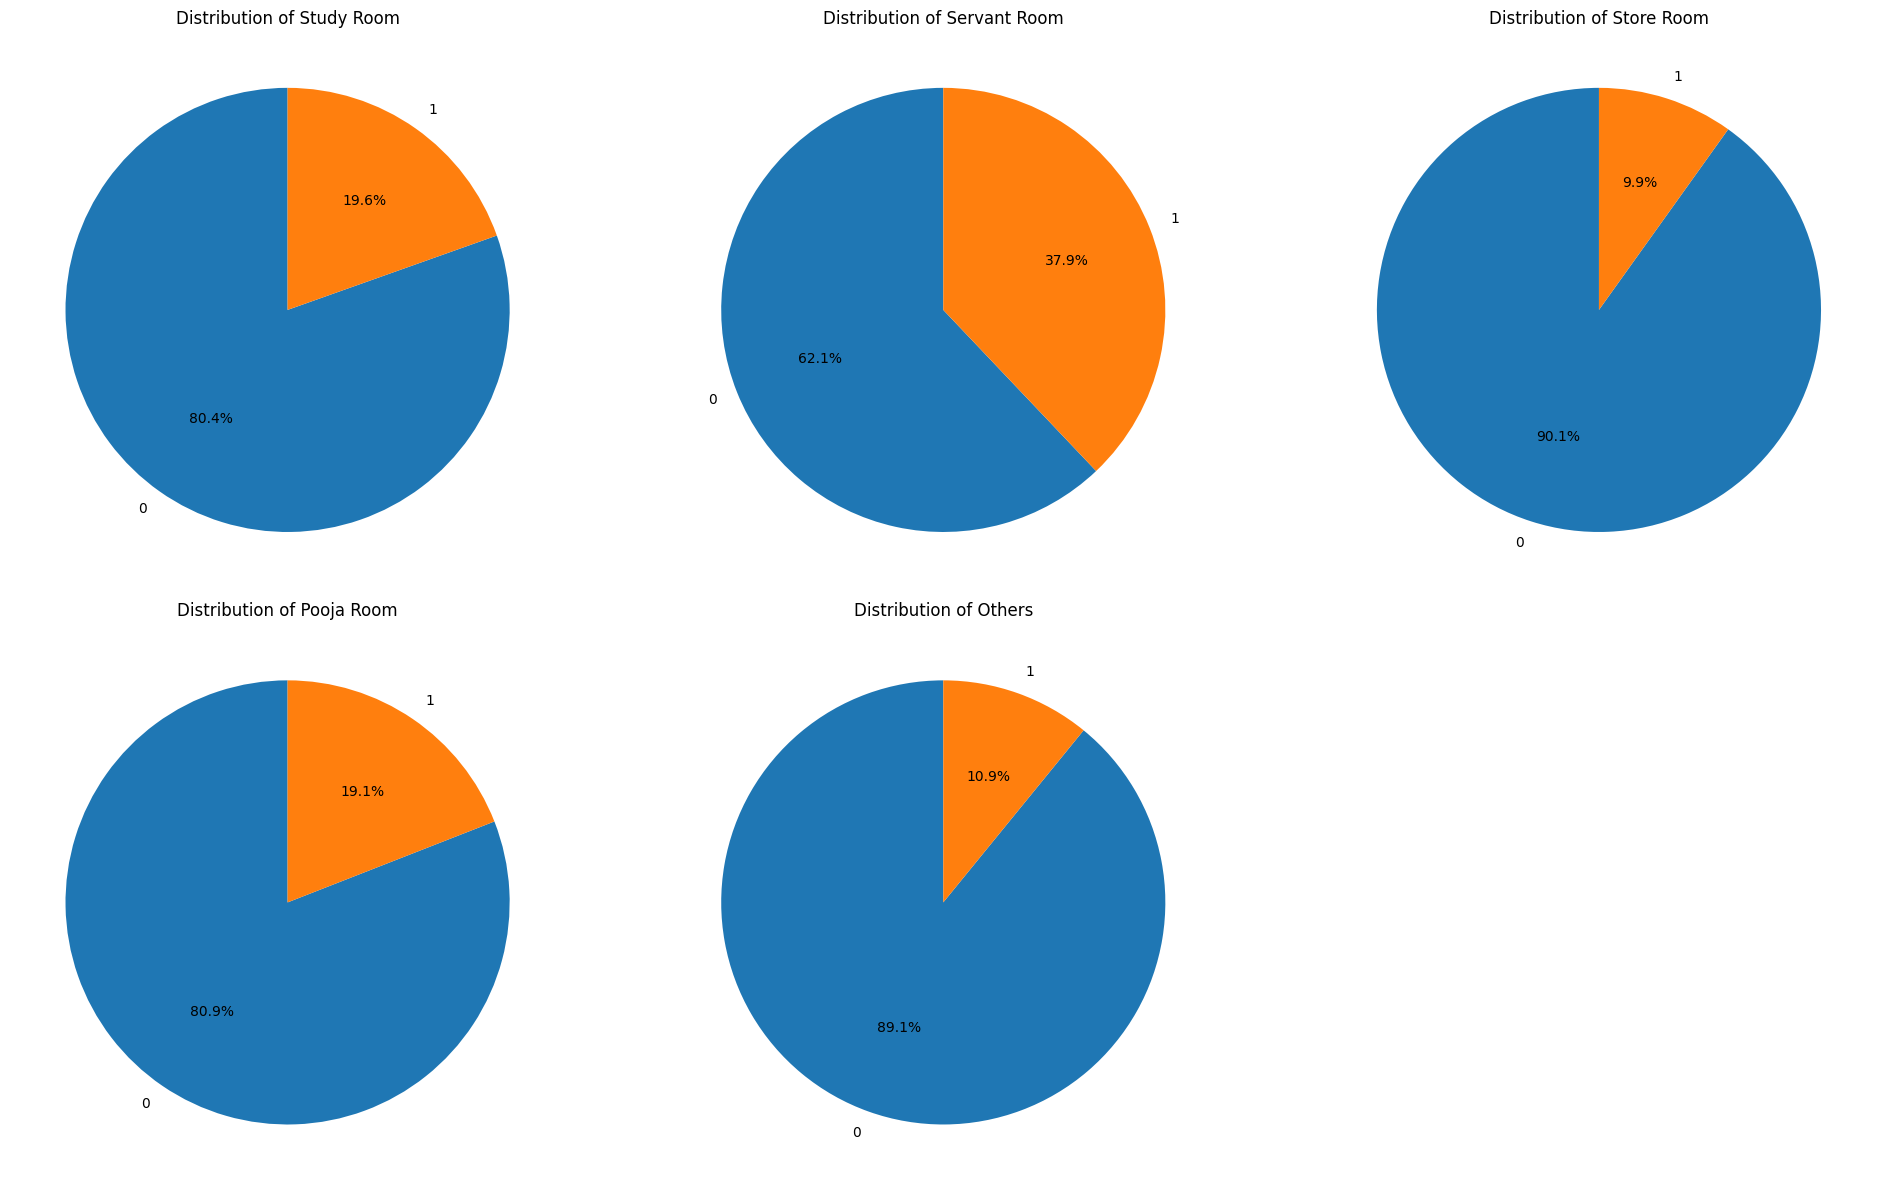

In [85]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()m

### 14. furnishing_type

In [86]:
df['furnishing_type'].value_counts()

,count
furnishing_type,
0,2191
1,1003
2,195


<Axes: ylabel='count'>

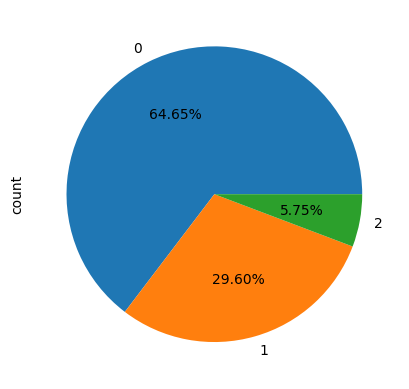

In [89]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

### 15. luxury_score

In [90]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [91]:
df['luxury_score'].describe()

,luxury_score
count,3389.000000
mean,73.670994
std,53.695895
min,0.000000
25%,35.000000
50%,60.000000
75%,113.000000
max,174.000000


<Axes: xlabel='luxury_score', ylabel='Count'>

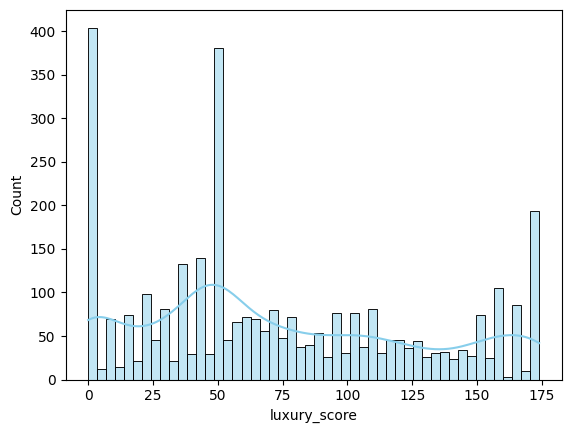

In [92]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

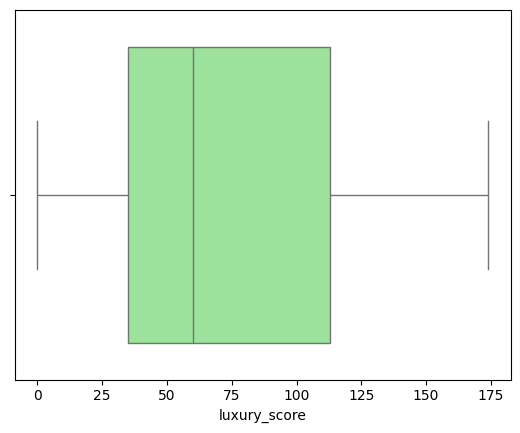

In [95]:
sns.boxplot(x=df['luxury_score'], color='lightgreen')

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [96]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5965.0,1459.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,...,1457.0,NaN,849.00,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,2087.0,Super Built up area 2087(193.89 sq.m.),4,4,2,...,2087.0,NaN,NaN,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,2086.0,Super Built up area 2086(193.8 sq.m.),3,3,3+,...,2086.0,NaN,NaN,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9210.0,1900.0,Super Built up area 1900(176.52 sq.m.)Built Up...,3,3,3,...,1900.0,1600.0,1240.04,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,1127.0,Super Built up area 1134(105.35 sq.m.),2,2,3+,...,1134.0,NaN,NaN,1,0,0,0,0,0,110
